# Análise Exploratória de Dados — Predição de Churn

## Objetivo

Este notebook tem como objetivo realizar a análise exploratória do dataset Telco Customer Churn, buscando compreender a estrutura dos dados, a qualidade das informações e a distribuição das variáveis relacionadas ao cancelamento de clientes.

Nesta etapa serão analisados:

- dimensões e estrutura do dataset;
- tipos das variáveis;
- valores ausentes e possíveis inconsistências;
- distribuição da variável-alvo `Churn`;
- comportamento das principais variáveis numéricas e categóricas;
- possíveis relações entre as características dos clientes e a ocorrência de churn.

Os resultados desta análise servirão de base para as decisões de pré-processamento e para o desenvolvimento dos modelos de Machine Learning.

In [ ]:
#Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Leitura dos dados
caminho_dados = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

dados = pd.read_csv(caminho_dados)

#Preview do dataset - Primeiras linhas
dados.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#Quais são as colunas
dados.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [6]:
#Quais os tipos de cada dado
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
#Investigação do porque MonthlyChanges é float e TotalCharges é string, mesmo ambas contendo valores monetários
dados["TotalCharges"].value_counts(dropna=False).sort_index().head(20)

TotalCharges
           11
100.2       1
100.25      1
100.35      1
100.4       1
100.8       1
100.9       1
1001.2      1
1001.5      1
1003.05     1
1004.35     1
1004.5      1
1004.75     1
1005.7      1
1006.9      1
1007.8      1
1007.9      1
1008.55     1
1008.7      2
1009.25     1
Name: count, dtype: int64

In [8]:
# tenure é o tempo que o cliente tem na empresa
dados[dados["TotalCharges"].str.strip() == ""][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [10]:
#Linhas completamente duplicadas
dados.duplicated().sum()

np.int64(0)

In [11]:
#ids duplicados
dados["customerID"].duplicated().sum()


np.int64(0)

In [12]:
#Avaliação da coluna churn
dados["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
#Proporção de churn
dados["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

# Distribuição da variável-alvo

A variável `Churn` apresenta desbalanceamento entre as classes:

- 73% dos clientes permaneceram na empresa (`No`);
- 27% dos clientes cancelaram o serviço (`Yes`).

Esse desbalanceamento deve ser considerado durante a avaliação dos modelos, pois a acurácia isoladamente pode fornecer uma visão inadequada do desempenho. Métricas alternativas como Precisão, Recall, F1 score e AUC ROC serão consideradas nas etapas de modelagem e avaliação.

In [15]:
#Voltando ao TotalCharges datatype

dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce") #como os casos de " " são poucos, podemos trasnformar em numeric sem dar um valor para estes campos

dados[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


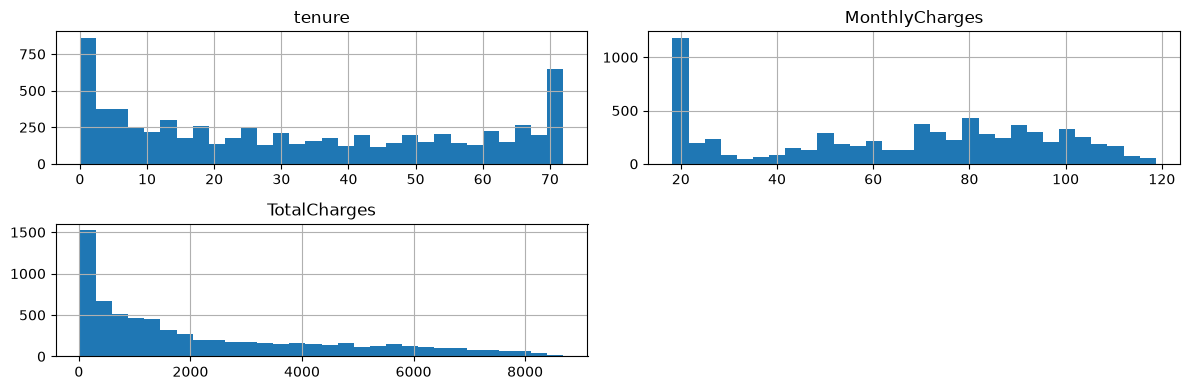

In [17]:
#Visualização das distribuições - histogramas
dados[["tenure", "MonthlyCharges", "TotalCharges"]].hist(
    bins=30,
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

# Análise das variáveis numéricas

As variáveis numéricas apresentam comportamentos distintos:

- tenure: varia de 0 - 72 meses e apresenta maior concentração de clientes nos primeiros meses de relacionamento, além de uma concentração relevante entre clientes com longo tempo de permanência.
- MonthlyCharges: varia de 18,25 a 118,75, com forte concentração próxima aos menores valores e distribuição das demais observações ao longo de uma faixa ampla de cobranças mensais.
- TotalCharges: apresenta distribuição assimétrica à direita, com maior concentração em valores baixos e redução gradual da frequência conforme o valor acumulado aumenta. Esse comportamento é coerente com sua relação com o tempo de permanência do cliente.

Após a conversão de `TotalCharges` para formato numérico, foram identificados 11 valores ausentes. Esses registros correspondem aos clientes com `tenure = 0` e serão tratados posteriormente durante a etapa de preparação dos dados.

In [18]:
#avaliação do comportamento das variáveis numéricas com a variável alvo
dados.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].median().round(2) 

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.43,1683.60
Yes,10.0,79.65,703.55


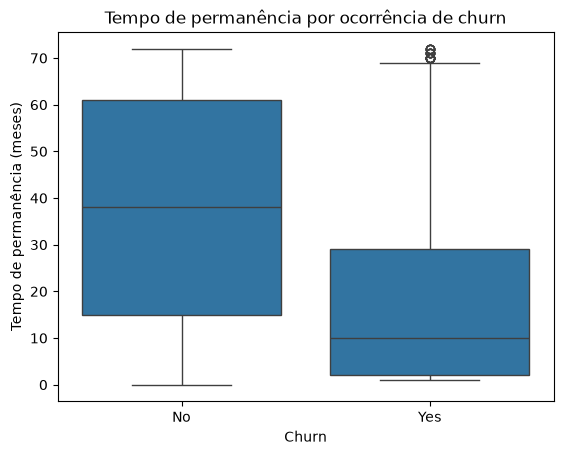

In [19]:
#A probabilidade de churn cai com o aumento do tempo de permanência?
sns.boxplot(
    data=dados,
    x="Churn",
    y="tenure"
)

plt.title("Tempo de permanência por ocorrência de churn")
plt.xlabel("Churn")
plt.ylabel("Tempo de permanência (meses)")
plt.show()


# Relação entre tempo de permanência e churn

O tempo de permanência apresenta uma diferença relevante entre os clientes que permaneceram e os que cancelaram o serviço.

A mediana de `tenure` é de aproximadamente 38 meses para os clientes sem churn e de apenas 10 meses para os clientes que apresentaram churn.

O boxplot mostra uma maior concentração de clientes com churn entre aqueles com menor tempo de relacionamento com a empresa. Apesar disso, também existem clientes com longo tempo de permanência que cancelaram o serviço.

Portanto, os resultados indicam uma associação entre menor tempo de permanência e maior ocorrência de churn, mas não permitem afirmar que o tempo de permanência, isoladamente, seja responsável pelo cancelamento.

Essa diferença sugere que `tenure` pode ser uma variável relevante para a capacidade preditiva dos modelos.

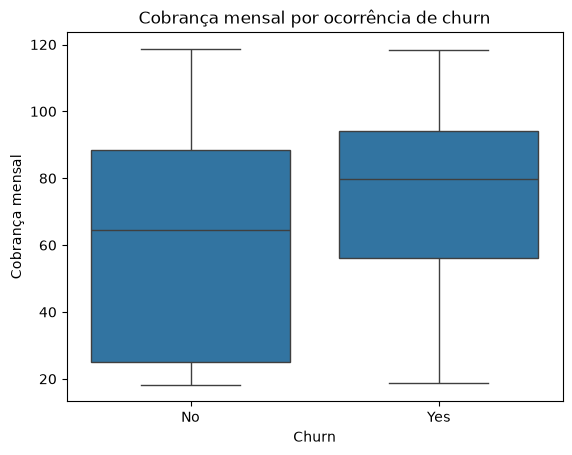

In [20]:
#O aumento no valor mensal contribui para o aumento na probabilidade de churn?
sns.boxplot(
    data=dados,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Cobrança mensal por ocorrência de churn")
plt.xlabel("Churn")
plt.ylabel("Cobrança mensal")
plt.show()

# Relação entre cobrança mensal e churn

A cobrança mensal também apresenta diferenças entre os grupos. A mediana de `MonthlyCharges` é de aproximadamente 79,65 entre os clientes que apresentaram churn, enquanto entre os clientes que permaneceram é de aproximadamente 64,43.

O boxplot mostra que clientes que cancelaram o serviço tendem a apresentar cobranças mensais mais elevadas. Entretanto, existe sobreposição entre as distribuições dos dois grupos, indicando que o valor da mensalidade não explica isoladamente a ocorrência de churn.

Esse comportamento sugere que `MonthlyCharges` pode contribuir para a capacidade preditiva dos modelos quando analisada em conjunto com outras características dos clientes.

In [21]:
#variáveis categóricas
variaveis_categoricas = dados.select_dtypes(include=["object", "str"]).columns.tolist()

variaveis_categoricas.remove("customerID")
variaveis_categoricas.remove("Churn")

for coluna in variaveis_categoricas:
    print(f"{coluna}: {dados[coluna].unique()}")

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract: <StringArray>
['Month-to-month', 'One year', '

In [22]:
# taxa de churn por tipo de contrato
taxa_churn_contrato = pd.crosstab(
    dados["Contract"],
    dados["Churn"],
    normalize="index"
).mul(100).round(2)

taxa_churn_contrato


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


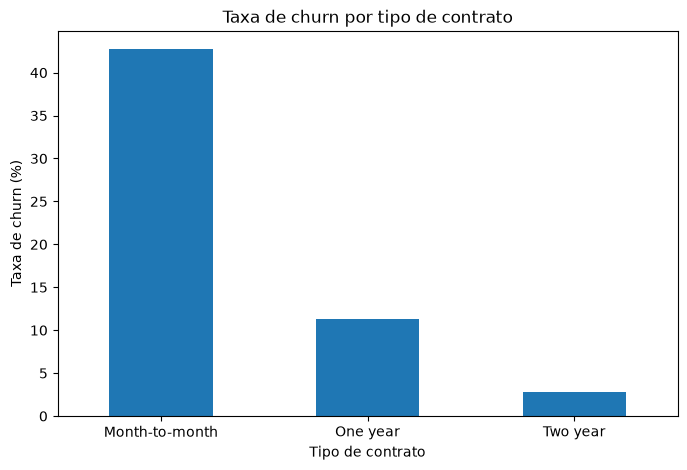

In [23]:
taxa_churn_contrato["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Taxa de churn por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Taxa de churn (%)")
plt.xticks(rotation=0)
plt.show()

# Relação entre tipo de contrato e churn

O tipo de contrato apresenta uma associação relevante com a ocorrência de churn.

Clientes com contrato Month-to-month apresentam taxa de churn de aproximadamente 43%, valor significativamente superior ao observado nos contratos de um ano (11%) e dois anos (3%).

Os resultados indicam que clientes vinculados a contratos de maior duração apresentam menor ocorrência de churn, enquanto clientes com contratos mensais formam um grupo com maior incidência de cancelamento.

Essa diferença sugere que a variável `Contract` pode apresentar importante capacidade preditiva nos modelos de classificação.

In [25]:
#tx de churn por serviço de internet
taxa_churn_internet = pd.crosstab(
    dados["InternetService"],
    dados["Churn"],
    normalize="index"
).mul(100).round(2)

taxa_churn_internet


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


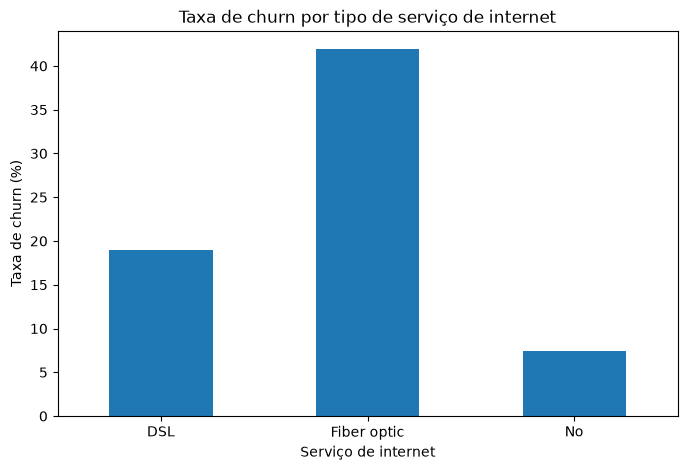

In [26]:
taxa_churn_internet["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Taxa de churn por tipo de serviço de internet")
plt.xlabel("Serviço de internet")
plt.ylabel("Taxa de churn (%)")
plt.xticks(rotation=0)
plt.show()

# Relação entre serviço de internet e churn

O tipo de serviço de internet apresenta diferenças relevantes na ocorrência de churn.

Clientes que utilizam fibra óptica (Fiber optic) apresentam a maior taxa de churn, aproximadamente 42%. Entre clientes com DSL, a taxa é de 19%, enquanto clientes que não possuem serviço de internet apresentam a menor taxa, aproximadamente 7%.

Os resultados indicam uma associação entre o tipo de serviço de internet e a ocorrência de churn, com destaque para a maior incidência de cancelamento entre clientes de fibra óptica.

Entretanto, essa relação não deve ser interpretada isoladamente como causal, pois características como valor da mensalidade, tipo de contrato e serviços adicionais podem estar relacionadas tanto ao tipo de conexão quanto ao churn.

A variável `InternetService` apresenta, portanto, potencial relevância para os modelos de classificação.

In [27]:
#tx de churn por método de pagamento
taxa_churn_pagamento = pd.crosstab(
    dados["PaymentMethod"],
    dados["Churn"],
    normalize="index"
).mul(100).round(2)

taxa_churn_pagamento

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


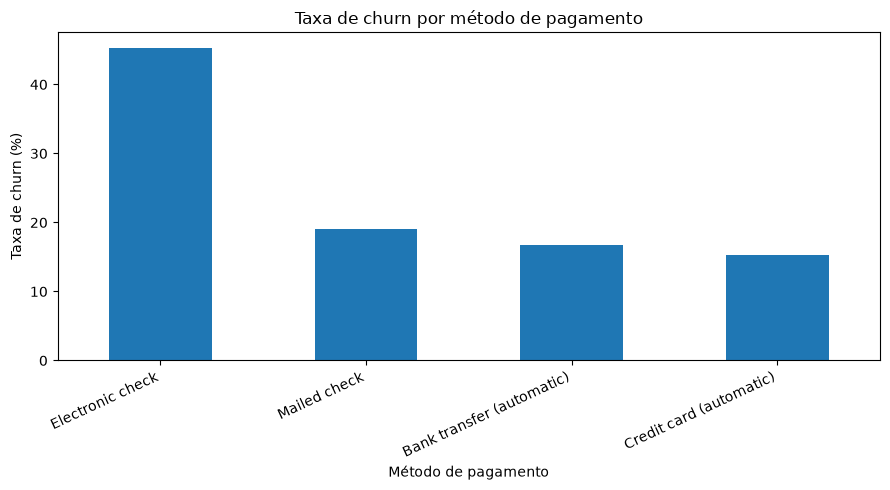

In [28]:
taxa_churn_pagamento["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Taxa de churn por método de pagamento")
plt.xlabel("Método de pagamento")
plt.ylabel("Taxa de churn (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Relação entre método de pagamento e churn

O método de pagamento apresenta diferenças relevantes na ocorrência de churn.

Clientes que utilizam Electronic check apresentam a maior taxa de churn, aproximadamente 45%. Nos demais métodos de pagamento, as taxas são consideravelmente menores: 19% para `Mailed check`, 17%** para transferência bancária automática e 15%** para cartão de crédito automático.

Os resultados indicam uma associação relevante entre `PaymentMethod` e a ocorrência de churn, com destaque para os clientes que utilizam cheque eletrônico.

Entretanto, essa relação não deve ser interpretada como causal, pois o método de pagamento pode estar associado a outras características, como tipo de contrato, perfil do cliente e tempo de permanência.

A variável `PaymentMethod` apresenta, portanto, potencial relevância para os modelos de classificação.

In [29]:
#tx de churn por serviços adicionais
servicos_internet = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for servico in servicos_internet:
    taxa_churn_servico = pd.crosstab(
        dados[servico],
        dados["Churn"],
        normalize="index"
    ).mul(100).round(2)

    print(f"\n{servico}")
    print(taxa_churn_servico["Yes"].sort_values(ascending=False))


OnlineSecurity
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Yes, dtype: float64

OnlineBackup
OnlineBackup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Yes, dtype: float64

DeviceProtection
DeviceProtection
No                     39.13
Yes                    22.50
No internet service     7.40
Name: Yes, dtype: float64

TechSupport
TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Yes, dtype: float64

StreamingTV
StreamingTV
No                     33.52
Yes                    30.07
No internet service     7.40
Name: Yes, dtype: float64

StreamingMovies
StreamingMovies
No                     33.68
Yes                    29.94
No internet service     7.40
Name: Yes, dtype: float64


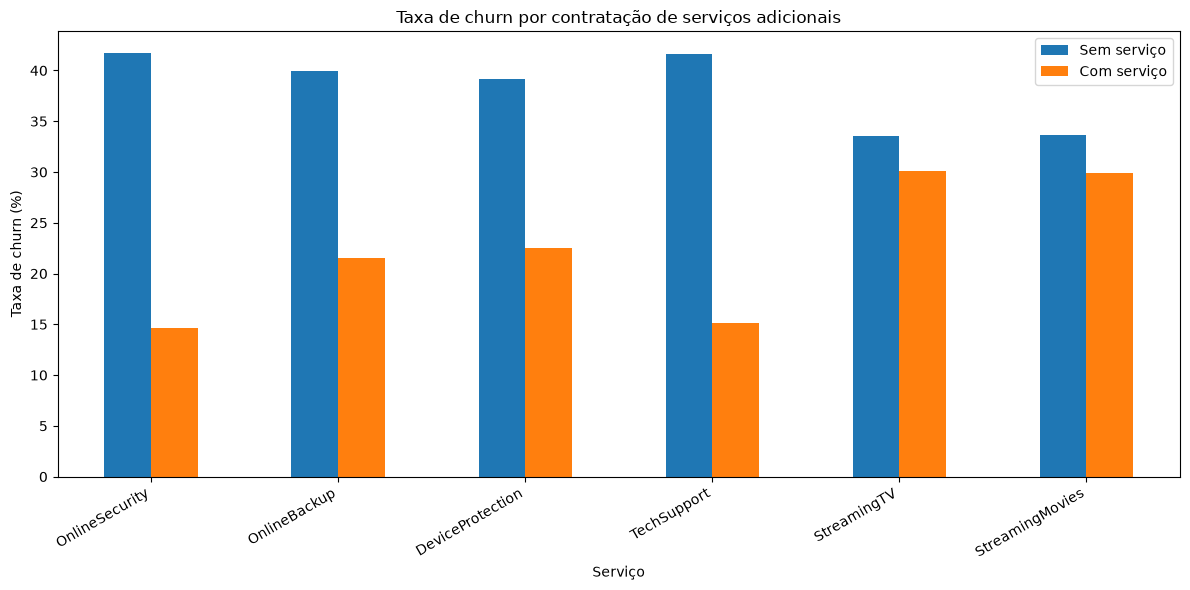

In [30]:
taxas_churn_servicos = {}

for servico in servicos_internet:
    taxas = pd.crosstab(
        dados[servico],
        dados["Churn"],
        normalize="index"
    ).mul(100)

    taxas_churn_servicos[servico] = {
        "Sem serviço": taxas.loc["No", "Yes"],
        "Com serviço": taxas.loc["Yes", "Yes"]
    }

taxas_churn_servicos = pd.DataFrame(taxas_churn_servicos).T

taxas_churn_servicos.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Taxa de churn por contratação de serviços adicionais")
plt.xlabel("Serviço")
plt.ylabel("Taxa de churn (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()

# Relação entre serviços adicionais e churn

A análise dos serviços adicionais de internet mostra diferenças relevantes na taxa de churn entre clientes que possuem e não possuem determinados serviços.

Os maiores contrastes foram observados em OnlineSecurity e TechSupport. Clientes sem segurança online apresentam taxa de churn de aproximadamente 48%, contra 15% entre aqueles que possuem o serviço. De forma semelhante, clientes sem suporte técnico apresentam churn de aproximadamente 42%, enquanto entre aqueles que possuem suporte a taxa é de 15%.

Também foram observadas diferenças em OnlineBackup e DeviceProtection, embora menos acentuadas.

Por outro lado, StreamingTV e StreamingMovies apresentam taxas de churn relativamente próximas entre clientes que possuem e não possuem esses serviços, sugerindo uma associação menos expressiva com o cancelamento.

Esses resultados indicam que serviços relacionados a segurança, suporte e proteção podem apresentar maior relevância preditiva para churn do que os serviços de streaming. As relações observadas são associativas e devem ser avaliadas em conjunto com as demais características dos clientes durante a modelagem.